In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a depende

In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
y1.sum()/y1.count()

Y    0.186475
dtype: float64

In [4]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [5]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=1, random_state=42)
X1, y1 = smote.fit_resample(X1, y1)
display(pd.DataFrame(X1))

,0,1,2,3,4,5,6,7,8,9,...,2390,2391,2392,2393,2394,2395,2396,2397,2398,2399
0,-0.296463,-1.014346,0.704087,0.197034,-0.199916,0.056990,-1.262282,-0.085669,-1.053805,0.296247,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.856668
1,-0.670941,-0.525577,-1.236676,1.502286,0.377970,-0.372174,-0.045401,-0.789457,0.021136,-0.509625,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.299228
2,0.629879,0.514115,-0.293469,1.144865,-1.295461,-1.086432,1.400654,1.220583,1.660234,-0.789349,...,-0.290593,6.044705,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.866536
3,0.373012,-1.030634,0.820882,0.936072,-0.378374,1.713116,1.237002,-0.435967,-0.914606,1.251034,...,-0.290593,-0.165434,1.105679,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.567226
4,-1.172401,0.684663,-0.397464,-1.756755,1.804830,0.697231,-0.604966,-1.927427,-0.766635,-1.374831,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,1.510832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
789,-1.193043,-0.487364,-0.908142,1.116066,-0.271553,-0.376130,-0.633163,0.123939,1.031423,0.226711,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.918624
790,1.125096,1.186714,-0.128442,-0.240725,-1.569522,-0.687927,1.238028,0.160632,-1.380454,0.755241,...,-0.290593,-0.165434,0.291367,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,0.891481
791,-0.823325,-0.610447,-0.668821,1.034534,-0.353845,-0.572354,-0.119446,0.004899,1.136635,0.244145,...,-0.290593,-0.165434,-0.601825,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.984171
792,-0.336960,-1.640396,-0.558868,0.358328,-0.148476,0.579681,-1.060386,0.396513,-0.133678,0.005032,...,-0.290593,-0.165434,0.437196,-0.120636,-0.322603,-0.237228,-0.160464,-0.331527,-0.101745,-0.059823


In [6]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit_transform(X1)
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1
from sklearn.decomposition import PCA
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

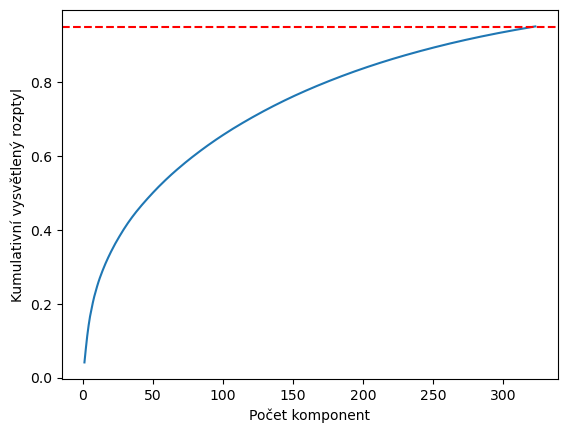

In [7]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [8]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=8)

In [9]:
pred = knn.predict(X2)

In [10]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.5870967741935483
Mcc: 0.1856131191693776


In [ ]:
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import pandas as pd
param_grid = ParameterGrid({
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21, 31],  # různé hodnoty K
    'weights': ['uniform', 'distance'],             # vážení sousedů
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],  # různé metriky vzdálenosti
    'p': [1, 2],                                     # pro minkowski: p=1 (Manhattan), p=2 (Eukleidovská)
    'leaf_size': [10, 20, 30, 50, 100],              # ovlivňuje rychlost vyhledávání
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']  # různé algoritmy pro hledání sousedů
})

val_mcc = []
val_f1 = []
val_acc = []
for param in tqdm(param_grid, total=len(param_grid)):
    knn = KNeighborsClassifier(**param)
    knn.fit(X1, y1["Y"])
    pred = knn.predict(X2)
    val_mcc.append(matthews_corrcoef(pred, y2["Y"]))
    val_f1.append(f1_score(pred, y2["Y"]))
    val_acc.append(accuracy_score(pred, y2["Y"]))
    print("Params:", param, "\nMCC:", matthews_corrcoef(pred, y2["Y"]))



In [13]:
knn_res = pd.DataFrame(param_grid)

In [14]:
knn_res["mcc"] = val_mcc
knn_res["f1"] = val_f1
knn_res["acc"] = val_acc

In [15]:
knn_res.sort_values(by=["mcc", "f1", "acc"], ascending=False, inplace=True)

In [18]:
knn_res.to_csv("res/knn_res_val_1.1.csv")

In [23]:
knn_res

,algorithm,leaf_size,metric,n_neighbors,p,weights,mcc,f1,acc
72,auto,10,chebyshev,1,1,uniform,0.362267,0.461538,0.819355
73,auto,10,chebyshev,1,1,distance,0.362267,0.461538,0.819355
74,auto,10,chebyshev,1,2,uniform,0.362267,0.461538,0.819355
75,auto,10,chebyshev,1,2,distance,0.362267,0.461538,0.819355
216,auto,20,chebyshev,1,1,uniform,0.362267,0.461538,0.819355
...,...,...,...,...,...,...,...,...,...
2801,brute,100,manhattan,21,1,distance,-0.164488,0.315217,0.187097
2802,brute,100,manhattan,21,2,uniform,-0.164488,0.315217,0.187097
2803,brute,100,manhattan,21,2,distance,-0.164488,0.315217,0.187097
2872,brute,100,minkowski,21,1,uniform,-0.164488,0.315217,0.187097


In [19]:
import numpy as np
best_params = param_grid[np.argmax(val_mcc)]

In [20]:
best_params

{'weights': 'uniform',
 'p': 1,
 'n_neighbors': 1,
 'metric': 'chebyshev',
 'leaf_size': 10,
 'algorithm': 'auto'}

In [21]:
knn = KNeighborsClassifier(**best_params)
knn.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(leaf_size=10, metric='chebyshev', n_neighbors=1, p=1)

In [22]:
pred = knn.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.8193548387096774
F1: 0.46153846153846156
Mcc: 0.36226673028138096


In [24]:
pred_test = knn.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))

Acc: 0.8109756097560976
F1: 0.43636363636363634
Mcc: 0.33796635315931106
